In [1]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#!pip3 install ultralytics
#!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


In [16]:
# Deep Learning
import torch
from torchvision import transforms
from ultralytics import YOLO
# Check for GPU availability
import tensorflow as tf
import os

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))



# Change the dataset path as needed (e.g., from Google Drive)
data_path = 'OS Collected Data'  # Update to your dataset path
dataset_dir = "OS Collected Data"  # Change as needed


# Assuming 'data_path' is already defined as in your provided code
dataset_folders = os.listdir(data_path)

print(f"Number of folders in dataset: {len(dataset_folders)}")

for dataset_folder in dataset_folders:
    num_images = len(os.listdir(os.path.join(data_path, dataset_folder)))
    print(f"Number of images in '{dataset_folder}': {num_images}")


Num GPUs Available:  0
Number of folders in dataset: 2
Number of images in 'normal': 372
Number of images in 'osteoporosis': 372


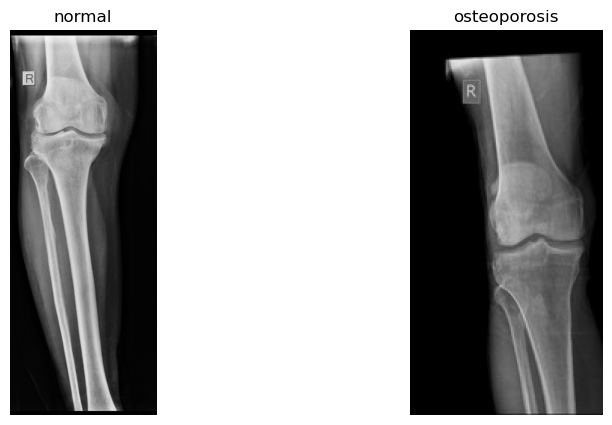

In [18]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# Assuming 'data_path' is already defined as in your provided code
dataset_folders = os.listdir(data_path)
data_dir_list = os.listdir(data_path)

plt.figure(figsize=(10, 5))  # Adjust figure size as needed
num_classes = len(dataset_folders)
for i, dataset_folder in enumerate(dataset_folders):
    image_files = os.listdir(os.path.join(data_path, dataset_folder))
    random_image_file = random.choice(image_files)  # Choose a random image
    image_path = os.path.join(data_path, dataset_folder, random_image_file)

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_classes, i + 1)  # Create subplots for each class
    plt.imshow(image_rgb)
    plt.title(dataset_folder)
    plt.axis('off')

plt.show()

HOG feature vector shape: (1176,)
GLCM matrix shape: (256, 256, 1, 1)
ORB descriptors shape: (105, 32)


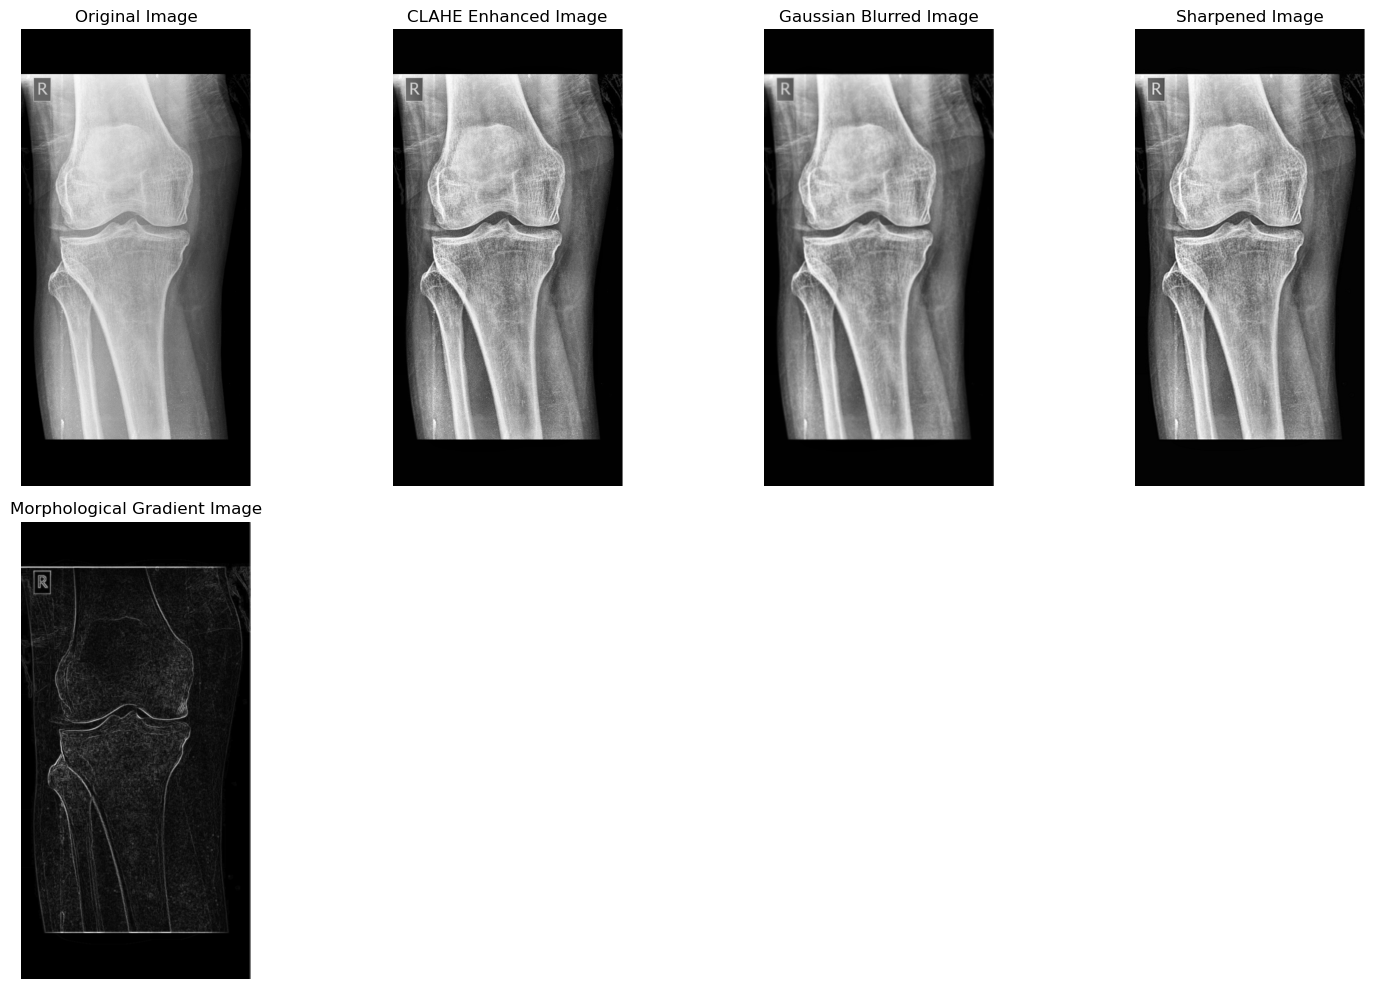

In [24]:
import cv2
import numpy as np
from skimage.feature import hog, graycomatrix, graycoprops
from skimage import exposure
import matplotlib.pyplot as plt

# Load the image
image_path = "OS Collected Data/osteoporosis/1.JPEG "

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Preprocessing Steps
# 1. Apply CLAHE to improve local contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_image = clahe.apply(image)

# 2. Apply Gaussian Blurring to reduce noise
blurred_image = cv2.GaussianBlur(enhanced_image, (5, 5), 0)

# 3. Sharpen the image
sharpening_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened_image = cv2.filter2D(blurred_image, -1, sharpening_kernel)

# 4. Morphological Gradient to highlight boundaries
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morphed_image = cv2.morphologyEx(sharpened_image, cv2.MORPH_GRADIENT, kernel)

# Resize the final preprocessed image
resized_image = cv2.resize(morphed_image, (128, 128))

# Feature Extraction
# 5. Extract HOG features
hog_features, hog_image = hog(
    resized_image,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    orientations=6,
    visualize=True,
    feature_vector=True
)

# 6. Extract GLCM features
glcm = graycomatrix(resized_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast')[0, 0]
dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]

# 7. Extract ORB keypoints and descriptors
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(resized_image, None)
orb_image = cv2.drawKeypoints(resized_image, keypoints, None, color=(0, 255, 0), flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

# Print shapes of extracted features
print(f"HOG feature vector shape: {hog_features.shape}")
print(f"GLCM matrix shape: {glcm.shape}")
print(f"ORB descriptors shape: {descriptors.shape if descriptors is not None else 'No descriptors detected'}")


# Visualization
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(2, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# CLAHE Enhanced Image
plt.subplot(2, 4, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title('CLAHE Enhanced Image')
plt.axis('off')

# Blurred Image
plt.subplot(2, 4, 3)
plt.imshow(blurred_image, cmap='gray')
plt.title('Gaussian Blurred Image')
plt.axis('off')

# Sharpened Image
plt.subplot(2, 4, 4)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image')
plt.axis('off')

# Morphological Gradient Image
plt.subplot(2, 4, 5)
plt.imshow(morphed_image, cmap='gray')
plt.title('Morphological Gradient Image')
plt.axis('off')

# Resized Image
""""plt.subplot(2, 4, 6)
plt.imshow(resized_image, cmap='gray')
plt.title('Resized Image (128x128)')
plt.axis('off')"""

plt.tight_layout()
plt.show()


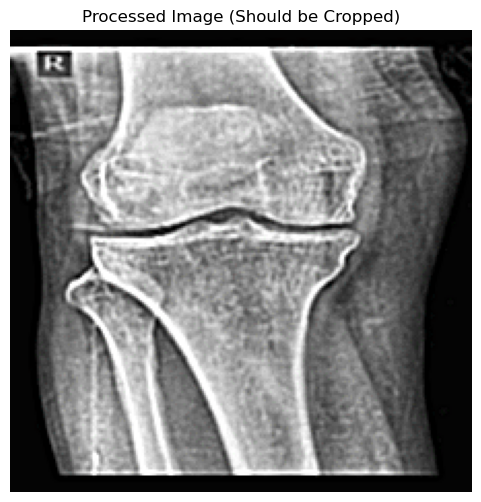

تمت المعالجة بنجاح! إذا ظهرت الركبة مقصوصة وبخلفية قليلة، فالكود يعمل.


In [26]:
# استيراد المكتبات اللازمة
import matplotlib.pyplot as plt
import importlib
import feature_extraction

# 1. إعادة تحميل الملف لضمان تطبيق التعديلات (مهم جداً بعد الريستارت)
importlib.reload(feature_extraction)
from feature_extraction import preprocess_knee

# 2. تحديد مسار صورة حقيقي من عندك
# تأكد من وضع مسار صحيح لصورة موجودة فعلياً
image_path = "OS Collected Data/osteoporosis/1.JPEG  " 
# (عدل هذا المسار حسب مكان صورك)

# 3. استدعاء الدالة الجديدة (التي تحتوي على القص)
try:
    img_processed = preprocess_knee(image_path)
    
    # 4. عرض الصورة الناتجة لترى بنفسك نتيجة القص
    plt.figure(figsize=(6, 6))
    plt.imshow(img_processed, cmap='gray') # أو cmap='rgb' إذا كانت ملونة
    plt.title("Processed Image (Should be Cropped)")
    plt.axis('off')
    plt.show()
    
    print("تمت المعالجة بنجاح! إذا ظهرت الركبة مقصوصة وبخلفية قليلة، فالكود يعمل.")
    
except Exception as e:
    print(f"حدث خطأ: {e}")
    print("تأكد من أن مسار الصورة صحيح")

In [28]:
import os
import random
import pickle
from sklearn.model_selection import train_test_split # استيراد دالة التقسيم

# 1. إعدادات
dataset_dir = "OS Collected Data"
TARGET_TRAIN_SAMPLES = 6000  # عدد عينات التدريب المطلوبة بعد التضخيم
PLAN_FILE = "data_plan.pkl"

# 2. جمع جميع الصور الموجودة وفصل المسارات والتسميات
all_images = []
all_labels = [] # سنحتاج التسميات لضمان تقسيم متوازن (Stratified Split)

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            all_images.append(img_path)
            # استخراج الليبل (اسم المجلد)
            label = os.path.basename(os.path.dirname(img_path))
            all_labels.append(label)

print(f"Found {len(all_images)} images. Splitting and generating plan...")

# ==========================================
# 3. التقسيم أولاً (Split First)
# نقسم البيانات الأصلية إلى 80% تدريب و 20% اختبار
# نستخدم random_state=42 لضمان تكرار نفس النتائج في كل مرة
# ==========================================
train_paths, test_paths, y_train, y_test = train_test_split(
    all_images, 
    all_labels, 
    test_size=0.2, 
    stratify=all_labels, # لضمان توازن الأصناف في التقسيم
    random_state=42
)

print(f"Original Train Images: {len(train_paths)}")
print(f"Original Test Images: {len(test_paths)} (No Augmentation will be applied to these)")

# ==========================================
# 4. بناء الخطة (Plan Generation)
# ==========================================
data_plan = []

# أ. خطة التدريب (Training Plan)
# نأخذ 6000 عينة من صور التدريب فقط ونطبق عليها التضخيم
for _ in range(TARGET_TRAIN_SAMPLES):
    img_path = random.choice(train_paths)
    label = os.path.basename(os.path.dirname(img_path))
    
    # أنواع التعديلات الممكنة للتدريب
    aug_type = random.choice(['none', 'flip', 'rotate', 'noise'])
    
    data_plan.append({
        'path': img_path,
        'label': label,
        'aug': aug_type
    })

# ب. خطة الاختبار (Test Plan)
# نأخذ صور الاختبار كما هي تماماً (بدون تعديل)
for img_path in test_paths:
    label = os.path.basename(os.path.dirname(img_path))
    
    # فرض عدم وجود تعديل لصور الاختبار
    data_plan.append({
        'path': img_path,
        'label': label,
        'aug': 'none' 
    })

# 5. حفظ الخطة في ملف
with open(PLAN_FILE, 'wb') as f:
    pickle.dump(data_plan, f)

print(f"Plan saved! Total items in plan: {len(data_plan)}")
print(f"(First {TARGET_TRAIN_SAMPLES} are Augmented Training, Last {len(test_paths)} are Original Testing)")

Found 744 images. Splitting and generating plan...
Original Train Images: 595
Original Test Images: 149 (No Augmentation will be applied to these)
Plan saved! Total items in plan: 6149
(First 6000 are Augmented Training, Last 149 are Original Testing)


Displaying Augmentations for: Normal_134.jpg


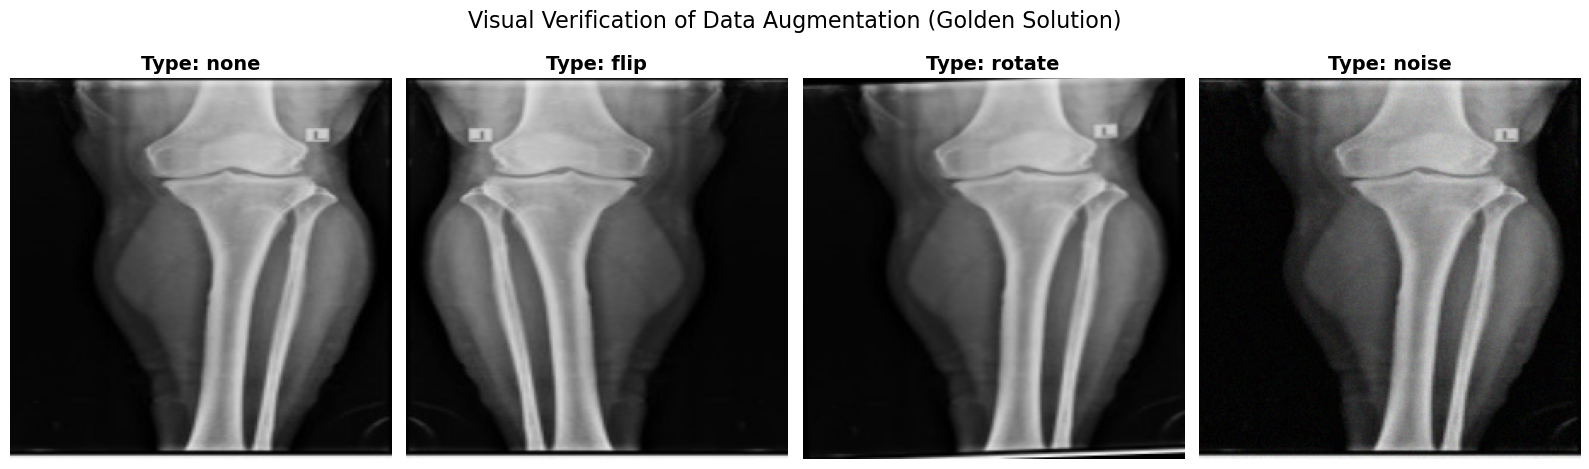

In [30]:
#هذا الكود فقط لعرض نماذج صور التدريب وممكن حذفة اذا لا تريد تعرض صور التدريب

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# 1. إعدادات المسار (تأكد أنه نفس المسار المستخدم في ملف binary)
dataset_dir = "OS Collected Data"

# 2. اختيار صورة عشوائية من البيانات للعرض
all_images = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

if len(all_images) == 0:
    print("لم يتم العثور على صور! تأكد من المسار.")
else:
    sample_path = random.choice(all_images)
    print(f"Displaying Augmentations for: {os.path.basename(sample_path)}")
    
    # تحميل الصورة الأصلية
    img_bgr = cv2.imread(sample_path)
    if img_bgr is not None:
        # التحويل إلى RGB للعرض الصحيح (لأن OpenCV يقرأ BGR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # تطبيق المعالجة المسبقة (Preprocessing) كما يفعل الكود الأصلي (التصغير لـ 224x224)
        img_processed = cv2.resize(img_rgb, (224, 224))

        # ==========================================
        # 3. تعريف دالة التعديل (Golden Solution)
        # (نسخة مطابقة لما وضعتها في الخلايا السابقة)
        # ==========================================
        def apply_augmentation_visual(img, aug_type):
            if aug_type == 'flip':
                return cv2.flip(img, 1)
            
            elif aug_type == 'rotate':
                # تدوير عشوائي بين -10 و 10
                angle = np.random.randint(-10, 10)
                h, w = img.shape[:2]
                center = (w // 2, h // 2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                return cv2.warpAffine(img, M, (w, h))
            
            elif aug_type == 'noise':
                # ضجيج خفيف + تباين
                noise = np.random.randint(0, 15, img.shape, dtype='uint8')
                img_noisy = cv2.add(img, noise)
                alpha = random.uniform(0.9, 1.1)
                beta = random.randint(-10, 10)
                return cv2.convertScaleAbs(img_noisy, alpha=alpha, beta=beta)
            
            return img # none

        # ==========================================
        # 4. تطبيق الحالات المختلفة
        # ==========================================
        aug_types = ['none', 'flip', 'rotate', 'noise']
        augmented_images = [apply_augmentation_visual(img_processed.copy(), t) for t in aug_types]

        # ==========================================
        # 5. عرض النتائج
        # ==========================================
        plt.figure(figsize=(16, 5)) # حجم كبير للعرض الواضح

        for i, (img_aug, aug_name) in enumerate(zip(augmented_images, aug_types)):
            plt.subplot(1, 4, i + 1)
            plt.imshow(img_aug)
            plt.title(f"Type: {aug_name}", fontsize=14, fontweight='bold')
            plt.axis('off')

        plt.suptitle("Visual Verification of Data Augmentation (Golden Solution)", fontsize=16)
        plt.tight_layout()
        plt.show()

In [32]:
# Feature Extraction Script ( for train stage)
import os
import numpy as np
import pandas as pd
import pickle
import cv2
from joblib import Parallel, delayed
from tqdm import tqdm
from feature_extraction import preprocess_knee, extract_hog_features, extract_glcm_features, extract_orb_features

# 1. تحميل الخطة
PLAN_FILE = "data_plan.pkl"
with open(PLAN_FILE, 'rb') as f:
    data_plan = pickle.load(f)

print(f"Loaded plan for {len(data_plan)} samples.")

# 2. دالة لتطبيق التعديل (Augmentation)
# === 2. دالة التعديل (Augmentation) - النسخة المحسنة طبياً ===
def apply_augmentation(img, aug_type):
    """
    هذه الدالة تحل محل الدالة القديمة في جميع الخلايا (6, 8, 10, 12, 14)
    لضمان منطق طبي سليم (تدوير بسيط، ضجيج منخفض، قلب آمن)
    """
    
    # 1. Horizontal Flip (آمن لتصنيف هشاشة العظام)
    if aug_type == 'flip':
        return cv2.flip(img, 1)
    
    # 2. Rotation (تصحيح: تدوير عشوائي صغير بدلاً من 90 درجة)
    elif aug_type == 'rotate':
        # تدوير بين -10 و +10 درجات فقط (لمحاكاة خطأ التصوير)
        angle = np.random.randint(-10, 10)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    
    # 3. Noise (ضجيج محسّن + إضافة تباين كبونوس)
    elif aug_type == 'noise':
        # تقليل الضجيج للحفاظ على نسيج العظم (من 25 إلى 15)
        noise = np.random.randint(0, 15, img.shape, dtype='uint8')
        img_noisy = cv2.add(img, noise)
        
        # --- إضافة ذكية: تغيير طفيف في التباين (Contrast) ---
        # بما أننا لا نستطيع إضافة نوع 'contrast' جديد لملف الخطة (pkl) بسهولة،
        # قمنا بإضافته هنا عشوائياً مع الضجيج لزيادة قوة النموذج.
        alpha = random.uniform(0.9, 1.1) # تباين
        beta = random.randint(-10, 10)   # سطوع
        img_final = cv2.convertScaleAbs(img_noisy, alpha=alpha, beta=beta)
        
        return img_final

    # إذا لم يطلب أي تعديل
    return img
    

# 3. دالة لمعالجة صورة واحدة (ستسمى من قبل الكود السريع)
def process_item(item):
    try:
        # تحميل وتجهيز الصورة
        img = preprocess_knee(item['path'], image_size=(224, 224))
        
        # تطبيق التعديل حسب الخطة
        img_aug = apply_augmentation(img, item['aug'])
        
        # استخراج الميزات
        hog_f, _ = extract_hog_features(img_aug)
        glcm_f = extract_glcm_features(img_aug)
        orb_f = extract_orb_features(img_aug)
        
        return (hog_f, glcm_f, orb_f, item['label'])
    except Exception as e:
        return None

# 4. التشغيل السريع (Parallel)
# n_jobs=-1 يعني استخدم كل سرعة الكمبيوتر
print("Starting FAST extraction...")
results = Parallel(n_jobs=-1)(
    delayed(process_item)(item) for item in tqdm(data_plan)
)

# 5. تنظيف النتائج وتحويلها لمصفوفات
hog_list, glcm_list, orb_list, labels_list = [], [], [], []

for res in results:
    if res is not None:
        h, g, o, l = res
        hog_list.append(h)
        glcm_list.append(g)
        orb_list.append(o)
        labels_list.append(l)

# التحويل لمصفوفات NumPy
hog_array = np.array(hog_list)
glcm_array = np.array(glcm_list)
orb_array = np.array(orb_list)
labels_array = np.array(labels_list)

print("Done!")
print(f"HOG: {hog_array.shape}, GLCM: {glcm_array.shape}, ORB: {orb_array.shape}")

Loaded plan for 6149 samples.
Starting FAST extraction...


100%|██████████████████████████████████████████████████████████████████████████████| 6149/6149 [04:05<00:00, 25.02it/s]


Done!
HOG: (6149, 1176), GLCM: (6149, 20), ORB: (6149, 500)


In [34]:
# Save features from each algorithm separately
#os.makedirs('Bin_Features', exist_ok=True)
import pandas as pd
df_hog = pd.DataFrame(hog_array)
df_hog['label'] = labels_array
df_hog.to_csv('Bin_Features/hog_features_array.csv', index=False)
df_glcm = pd.DataFrame(glcm_array)
df_glcm['label'] = labels_array
df_glcm.to_csv('Bin_Features/glcm_features_array.csv', index=False)
df_orb = pd.DataFrame(orb_array)
df_orb['label'] = labels_array
df_orb.to_csv('Bin_Features/orb_features_array.csv', index=False)
print('Saved features for each algorithm and  features/labels as .npy files.')
print('HOG features shape:', df_hog.shape)
print('GLCM features shape:', df_glcm.shape)
print('ORB features shape:', df_orb.shape)


Saved features for each algorithm and  features/labels as .npy files.
HOG features shape: (6149, 1177)
GLCM features shape: (6149, 21)
ORB features shape: (6149, 501)


In [ ]:
# YOLO Feature Extraction (train stage)
import os
import numpy as np
import cv2
from PIL import Image
import torch
from ultralytics import YOLO
from tqdm import tqdm
import pickle
import pandas as pd

# استيراد دالة المعالجة القياسية من الملف الخارجي (لضمان التطابق)
from feature_extraction import preprocess_knee

# تحميل النموذج
yolo_model = YOLO('yolov11m.pt')

# === 1. تحميل الخطة (Plan) ===
PLAN_FILE = "data_plan.pkl"
try:
    with open(PLAN_FILE, 'rb') as f:
        data_plan = pickle.load(f)
    print(f"Successfully loaded plan with {len(data_plan)} samples.")
except FileNotFoundError:
    print("Error: 'data_plan.pkl' not found. Please run the 'Plan Generation' cell first.")
    # Stop execution or handle error
    raise SystemExit

# === 2. دالة التعديل (Augmentation) ===
# === 2. دالة التعديل (Augmentation) - النسخة المحسنة طبياً ===
def apply_augmentation(img, aug_type):
    """
    هذه الدالة تحل محل الدالة القديمة في جميع الخلايا (6, 8, 10, 12, 14)
    لضمان منطق طبي سليم (تدوير بسيط، ضجيج منخفض، قلب آمن)
    """
    
    # 1. Horizontal Flip (آمن لتصنيف هشاشة العظام)
    if aug_type == 'flip':
        return cv2.flip(img, 1)
    
    # 2. Rotation (تصحيح: تدوير عشوائي صغير بدلاً من 90 درجة)
    elif aug_type == 'rotate':
        # تدوير بين -10 و +10 درجات فقط (لمحاكاة خطأ التصوير)
        angle = np.random.randint(-10, 10)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    
    # 3. Noise (ضجيج محسّن + إضافة تباين كبونوس)
    elif aug_type == 'noise':
        # تقليل الضجيج للحفاظ على نسيج العظم (من 25 إلى 15)
        noise = np.random.randint(0, 15, img.shape, dtype='uint8')
        img_noisy = cv2.add(img, noise)
        
        # --- إضافة ذكية: تغيير طفيف في التباين (Contrast) ---
        # بما أننا لا نستطيع إضافة نوع 'contrast' جديد لملف الخطة (pkl) بسهولة،
        # قمنا بإضافته هنا عشوائياً مع الضجيج لزيادة قوة النموذج.
        alpha = random.uniform(0.9, 1.1) # تباين
        beta = random.randint(-10, 10)   # سطوع
        img_final = cv2.convertScaleAbs(img_noisy, alpha=alpha, beta=beta)
        
        return img_final

    # إذا لم يطلب أي تعديل
    return img
    

# === 3. دالة استخراج ميزات YOLO (كما هي في الكود الأصلي) ===
def extract_yolo_features(image_array, yolo_model):
    # التأكد من أن الصورة float وبين 0 و 1
    if image_array.max() > 1.0:
        image_array = image_array.astype(np.float32) / 255.0
        
    img_uint8 = (image_array * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_uint8)
    
    results = yolo_model.predict(pil_image, verbose=False, device='cpu', conf=0.1)
    if results and len(results) > 0:
        result = results[0]
        features_list = []
        if result.boxes is not None and len(result.boxes) > 0:
            boxes = result.boxes
            if boxes.xywhn is not None:
                coords = boxes.xywhn.cpu().numpy().flatten()
                features_list.extend(coords)
            if boxes.conf is not None:
                confidences = boxes.conf.cpu().numpy()
                features_list.extend(confidences)
            if boxes.cls is not None:
                classes = boxes.cls.cpu().numpy()
                features_list.extend(classes)
        img_stats = [np.mean(image_array), np.std(image_array), np.min(image_array), np.max(image_array), len(result.boxes) if result.boxes is not None else 0]
        features_list.extend(img_stats)
        feature_size = 128
        features = np.zeros(feature_size)
        if len(features_list) > 0:
            features[:min(len(features_list), feature_size)] = features_list[:min(len(features_list), feature_size)]
        return features
    else:
        return np.zeros(128)

# === 4. التكرار على الخلية وتطبيق التعديلات ===
yolo_list = []
labels_list = []

print("Extracting YOLO features with progress bar...")

# التكرار على الخطة بدلاً من مجلد الصور
for item in tqdm(data_plan, desc="YOLO Feature Extraction", unit="img"):
    try:
        # أ. المعالجة الأولية (تستخدم الدالة المستوردة)
        # ملاحظة: الدالة المستوردة تعيد صورة من 0-255، وحجم 224 افتراضياً لذا نحدد الحجم 640 هنا
        img = preprocess_knee(item['path'], image_size=(640, 640))
        
        # ب. تطبيق التعديل
        img_aug = apply_augmentation(img, item['aug'])
        
        # ج. التطبيع (Normalization) لدالة YOLO (تحويل من 0-255 إلى 0.0-1.0)
        img_norm = img_aug.astype(np.float32) / 255.0
        
        # د. استخراج الميزات
        yolo_features = extract_yolo_features(img_norm, yolo_model)
        
        yolo_list.append(yolo_features)
        labels_list.append(item['label'])
    except Exception as e:
        # print(f"Error processing {item['path']}: {e}") # للتصحيح
        continue

yolo_array = np.array(yolo_list)
labels_array = np.array(labels_list)

# === 5. الحفظ ===
df_yolo = pd.DataFrame(yolo_array)
df_yolo['label'] = labels_array
df_yolo.to_csv('Bin_Features/yolo_features_array.csv', index=False)
print('YOLO features shape:', df_yolo.shape)

Successfully loaded plan with 6149 samples.
Extracting YOLO features with progress bar...


YOLO Feature Extraction:  39%|██████████████████▌                             | 2376/6149 [1:03:38<1:29:10,  1.42s/img]

In [ ]:
df_yolo = pd.DataFrame(yolo_array)
df_yolo['label'] = labels_array
df_yolo.to_csv('Bin_Features/yolo_features_array.csv', index=False)
print('YOLO features shape:', df_yolo.shape)


In [ ]:
# Feature Extraction Script ( ---- VGG -------for train stage)
import os
import numpy as np
import pickle
import cv2
from tqdm import tqdm
from feature_extraction import preprocess_knee

# === التعديل الهام هنا: استيراد preprocess_input من vgg16 تحديداً ===
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image

vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg')

# === 1. تحميل الخطة (Plan) ===
PLAN_FILE = "data_plan.pkl"
try:
    with open(PLAN_FILE, 'rb') as f:
        data_plan = pickle.load(f)
    print(f"Successfully loaded plan with {len(data_plan)} samples.")
except FileNotFoundError:
    print("Error: 'data_plan.pkl' not found. Please run the 'Plan Generation' cell first.")
    raise SystemExit

# === 2. دالة التعديل (Augmentation) ===
# === 2. دالة التعديل (Augmentation) - النسخة المحسنة طبياً ===
def apply_augmentation(img, aug_type):
    """
    هذه الدالة تحل محل الدالة القديمة في جميع الخلايا (6, 8, 10, 12, 14)
    لضمان منطق طبي سليم (تدوير بسيط، ضجيج منخفض، قلب آمن)
    """
    
    # 1. Horizontal Flip (آمن لتصنيف هشاشة العظام)
    if aug_type == 'flip':
        return cv2.flip(img, 1)
    
    # 2. Rotation (تصحيح: تدوير عشوائي صغير بدلاً من 90 درجة)
    elif aug_type == 'rotate':
        # تدوير بين -10 و +10 درجات فقط (لمحاكاة خطأ التصوير)
        angle = np.random.randint(-10, 10)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    
    # 3. Noise (ضجيج محسّن + إضافة تباين كبونوس)
    elif aug_type == 'noise':
        # تقليل الضجيج للحفاظ على نسيج العظم (من 25 إلى 15)
        noise = np.random.randint(0, 15, img.shape, dtype='uint8')
        img_noisy = cv2.add(img, noise)
        
        # --- إضافة ذكية: تغيير طفيف في التباين (Contrast) ---
        # بما أننا لا نستطيع إضافة نوع 'contrast' جديد لملف الخطة (pkl) بسهولة،
        # قمنا بإضافته هنا عشوائياً مع الضجيج لزيادة قوة النموذج.
        alpha = random.uniform(0.9, 1.1) # تباين
        beta = random.randint(-10, 10)   # سطوع
        img_final = cv2.convertScaleAbs(img_noisy, alpha=alpha, beta=beta)
        
        return img_final

    # إذا لم يطلب أي تعديل
    return img

# Prepare lists
vgg_list = []
labels_list = []

print("Processing images with VGG16 feature extraction...")

# === 3. التكرار على الخلية وتطبيق التعديلات ===
for item in tqdm(data_plan, desc="Extracting VGG features", unit="img"):
    try:
        # أ. المعالجة الأولية (الحجم 224x224)
        img = preprocess_knee(item['path'], image_size=(224, 224))
        
        # ب. تطبيق التعديل
        img_aug = apply_augmentation(img, item['aug'])
        
        # ج. تجهيز الصورة لـ VGG (Keras)
        img_vgg = image.img_to_array(img_aug)
        img_vgg = np.expand_dims(img_vgg, axis=0)
        img_vgg = preprocess_input(img_vgg)
    
        # د. استخراج الميزات
        features = vgg_model.predict(img_vgg, verbose=0)
        vgg_list.append(features.flatten())
        
        # هـ. حفظ الليبل من الخطة
        labels_list.append(item['label'])
        
    except Exception as e:
        # في حال حدوث خطأ مع صورة معينة، نتجاوزها
        tqdm.write(f"Error processing {item['path']}: {e}")
        continue

# Convert to numpy arrays
vgg_array = np.array(vgg_list) if vgg_list else None
labels_array = np.array(labels_list) if labels_list else None

print("Feature extraction complete.")
if vgg_array is not None:
    print(f"VGG features shape: {vgg_array.shape}")
print("-------------------- Finsh Feature Exctraction  --------------")

In [ ]:
import pandas as pd
df_vgg = pd.DataFrame(vgg_array)
df_vgg['label'] = labels_array
df_vgg.to_csv('Bin_Features/vgg_features_array.csv', index=False)
print('VGG features shape:', df_vgg.shape)


In [ ]:
df_res = pd.DataFrame(resnet_array)
df_res['label'] = labels_array
df_res.to_csv('Bin_Features/resnet_features_array.csv', index=False)
print('ResNet features shape:', df_res.shape)


In [ ]:
# Feature Extraction Script ( Resnet 50 for train stage)
import os
import numpy as np
import cv2  # تمت الإضافة
import pickle  # تمت الإضافة
from tqdm import tqdm  # تمت الإضافة (كانت مفقودة)
from feature_extraction import preprocess_knee

# Load ResNet Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

# === 1. تحميل الخطة (Plan) ===
PLAN_FILE = "data_plan.pkl"
try:
    with open(PLAN_FILE, 'rb') as f:
        data_plan = pickle.load(f)
    print(f"Successfully loaded plan with {len(data_plan)} samples.")
except FileNotFoundError:
    print("Error: 'data_plan.pkl' not found. Please run the 'Plan Generation' cell first.")
    raise SystemExit

# === 2. دالة التعديل (Augmentation) ===
# === 2. دالة التعديل (Augmentation) - النسخة المحسنة طبياً ===
def apply_augmentation(img, aug_type):
    """
    هذه الدالة تحل محل الدالة القديمة في جميع الخلايا (6, 8, 10, 12, 14)
    لضمان منطق طبي سليم (تدوير بسيط، ضجيج منخفض، قلب آمن)
    """
    
    # 1. Horizontal Flip (آمن لتصنيف هشاشة العظام)
    if aug_type == 'flip':
        return cv2.flip(img, 1)
    
    # 2. Rotation (تصحيح: تدوير عشوائي صغير بدلاً من 90 درجة)
    elif aug_type == 'rotate':
        # تدوير بين -10 و +10 درجات فقط (لمحاكاة خطأ التصوير)
        angle = np.random.randint(-10, 10)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    
    # 3. Noise (ضجيج محسّن + إضافة تباين كبونوس)
    elif aug_type == 'noise':
        # تقليل الضجيج للحفاظ على نسيج العظم (من 25 إلى 15)
        noise = np.random.randint(0, 15, img.shape, dtype='uint8')
        img_noisy = cv2.add(img, noise)
        
        # --- إضافة ذكية: تغيير طفيف في التباين (Contrast) ---
        # بما أننا لا نستطيع إضافة نوع 'contrast' جديد لملف الخطة (pkl) بسهولة،
        # قمنا بإضافته هنا عشوائياً مع الضجيج لزيادة قوة النموذج.
        alpha = random.uniform(0.9, 1.1) # تباين
        beta = random.randint(-10, 10)   # سطوع
        img_final = cv2.convertScaleAbs(img_noisy, alpha=alpha, beta=beta)
        
        return img_final

    # إذا لم يطلب أي تعديل
    return img

# Prepare lists to hold features and labels
resnet_list = []
labels_list = []

print("Starting ResNet50 feature extraction...")

# === 3. التكرار على الخلية وتطبيق التعديلات ===
for item in tqdm(data_plan, desc="Extracting ResNet50 features", unit="img"):
    try: 
        # أ. المعالجة الأولية (الحجم 224x224)
        img = preprocess_knee(item['path'], image_size=(224, 224))
        
        # ب. تطبيق التعديل
        img_aug = apply_augmentation(img, item['aug'])
        
        # ج. تجهيز الصورة لـ ResNet
        # ملاحظة: قمنا بإزالة cv2.resize الإضافية لأن preprocess_knee قامت بالفعل بذلك
        img_resnet = keras_image.img_to_array(img_aug)
        img_resnet = np.expand_dims(img_resnet, axis=0)
        img_resnet = resnet_preprocess(img_resnet)
        
        # د. استخراج الميزات
        features = resnet_model.predict(img_resnet, verbose=0)
        resnet_list.append(features.flatten())

        # هـ. حفظ الليبل من الخطة
        labels_list.append(item['label'])
        
    except Exception as e:
        tqdm.write(f"Error processing {item['path']}: {e}")
        continue

# Convert to numpy arrays
resnet_array = np.array(resnet_list) if resnet_list else None
labels_array = np.array(labels_list) if labels_list else None

print("Feature extraction complete.")
if resnet_array is not None:
    print(f"ResNet features shape: {resnet_array.shape}")
print("-------------------- Finsh Feature Exctraction  --------------")

In [ ]:
# SqueezeNet Feature Extraction using PyTorch
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import cv2  # للتعديل
import pickle  # لتحميل الخطة
import pandas as pd  # للحفظ
from tqdm import tqdm  # لشريط التقدم

# Load SqueezeNet model
squeezenet = models.squeezenet1_1(pretrained=True)
squeezenet.eval()  # Set to evaluation mode

# Define preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# === 1. تحميل الخطة (Plan) ===
PLAN_FILE = "data_plan.pkl"
try:
    with open(PLAN_FILE, 'rb') as f:
        data_plan = pickle.load(f)
    print(f"Successfully loaded plan with {len(data_plan)} samples.")
except FileNotFoundError:
    print("Error: 'data_plan.pkl' not found. Please run the 'Plan Generation' cell first.")
    raise SystemExit

# === 2. دالة التعديل (Augmentation) ===
# === 2. دالة التعديل (Augmentation) - النسخة المحسنة طبياً ===
def apply_augmentation(img, aug_type):
    """
    هذه الدالة تحل محل الدالة القديمة في جميع الخلايا (6, 8, 10, 12, 14)
    لضمان منطق طبي سليم (تدوير بسيط، ضجيج منخفض، قلب آمن)
    """
    
    # 1. Horizontal Flip (آمن لتصنيف هشاشة العظام)
    if aug_type == 'flip':
        return cv2.flip(img, 1)
    
    # 2. Rotation (تصحيح: تدوير عشوائي صغير بدلاً من 90 درجة)
    elif aug_type == 'rotate':
        # تدوير بين -10 و +10 درجات فقط (لمحاكاة خطأ التصوير)
        angle = np.random.randint(-10, 10)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    
    # 3. Noise (ضجيج محسّن + إضافة تباين كبونوس)
    elif aug_type == 'noise':
        # تقليل الضجيج للحفاظ على نسيج العظم (من 25 إلى 15)
        noise = np.random.randint(0, 15, img.shape, dtype='uint8')
        img_noisy = cv2.add(img, noise)
        
        # --- إضافة ذكية: تغيير طفيف في التباين (Contrast) ---
        # بما أننا لا نستطيع إضافة نوع 'contrast' جديد لملف الخطة (pkl) بسهولة،
        # قمنا بإضافته هنا عشوائياً مع الضجيج لزيادة قوة النموذج.
        alpha = random.uniform(0.9, 1.1) # تباين
        beta = random.randint(-10, 10)   # سطوع
        img_final = cv2.convertScaleAbs(img_noisy, alpha=alpha, beta=beta)
        
        return img_final

    # إذا لم يطلب أي تعديل
    return img

features_list = []
labels_list = []

print("Extracting SqueezeNet features based on the plan...")

# === 3. التكرار على الخلية وتطبيق التعديلات ===
for item in tqdm(data_plan, desc="Processing SqueezeNet"):
    try:
        # أ. تحميل الصورة كـ PIL
        image_pil = Image.open(item['path']).convert('RGB')
        
        # ب. تحويلها إلى Numpy لتطبيق التعديل
        image_np = np.array(image_pil)
        
        # ج. تطبيق التعديل
        image_aug_np = apply_augmentation(image_np, item['aug'])
        
        # د. إعادتها لـ PIL لكي تقبلها مكتبة PyTorch
        image_aug_pil = Image.fromarray(image_aug_np)
        
        # هـ. التحويلات الخاصة بـ PyTorch
        input_tensor = preprocess(image_aug_pil)
        input_batch = input_tensor.unsqueeze(0)  # Add batch dimension
        
        with torch.no_grad():
            # Extract features from the 'features' layer
            features = squeezenet.features(input_batch)
            # Global average pooling to get a single feature vector
            pooled = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
            feature_vector = pooled.view(-1).cpu().numpy()
            
        features_list.append(feature_vector)
        labels_list.append(item['label'])
        
    except Exception as e:
        print(f"Error processing {item['path']}: {e}")
        continue

# Convert to arrays
features_array = np.array(features_list)
labels_array = np.array(labels_list)

print(f"SqueezeNet features shape: {features_array.shape}")
print(f"Labels shape: {labels_array.shape}")

# === 4. الحفظ بصيغة CSV (للتوافق مع باقي الملفات) ===
df_squeeze = pd.DataFrame(features_array)
df_squeeze['label'] = labels_array
df_squeeze.to_csv('Bin_Features/squeezenet_features_array.csv', index=False)

print("Saved SqueezeNet features and labels to CSV.")
print("-------------------- Finsh Feature Exctraction  --------------")

In [ ]:




df_res = pd.DataFrame(features_array)
df_res['label'] = labels_array
df_res.to_csv('Bin_Features/squeezenet_features_array.csv', index=False)
print('SqueezeNet features shape:', df_res.shape)



In [ ]:
import pandas as pd
import numpy as np

# Load features from CSV files
df_hog = pd.read_csv('Bin_Features/hog_features_array.csv')
featuresHOG = df_hog.drop('label', axis=1).values

df_glcm = pd.read_csv('Bin_Features/glcm_features_array.csv')
featuresGLCM = df_glcm.drop('label', axis=1).values

df_orb = pd.read_csv('Bin_Features/orb_features_array.csv')
featuresORB = df_orb.drop('label', axis=1).values

# Concatenate features along axis 1
combined_features = np.concatenate([featuresHOG, featuresGLCM, featuresORB], axis=1)

# Use labels from one of the DataFrames (assuming they are the same)
labels = df_hog['label'].values

# Save combined features and labels to CSV
df_combined = pd.DataFrame(combined_features)
df_combined['label'] = labels
df_combined.to_csv('Bin_Features/combined_ML_features_array.csv', index=False)
print('Saved combined ML features and labels to final_Features/combined_ML_features_array.csv')
print('HOG features shape:', featuresHOG.shape)
print('GLCM features shape:', featuresGLCM.shape)
print('ORB features shape:', featuresORB.shape)
print('Combined ML features shape:', combined_features.shape)
print('Labels shape:', labels.shape)

In [ ]:
# Load feature arrays (VGG, YOLO, ResNet, SqueezeNet) and combine them
# Load features from CSV files
df_vgg = pd.read_csv('Bin_Features/vgg_features_array.csv')
featuresVGG = df_vgg.drop('label', axis=1).values

df_yolo = pd.read_csv('Bin_Features/yolo_features_array.csv')
featuresYOLO = df_yolo.drop('label', axis=1).values

df_resnet = pd.read_csv('Bin_Features/resnet_features_array.csv')
featuresResNet = df_resnet.drop('label', axis=1).values

df_squeeze = pd.read_csv('Bin_Features/squeezenet_features_array.csv')
featuressqueezenet = df_squeeze.drop('label', axis=1).values

# Combine features along the last axis (if shapes are compatible)
combined_DL_features = np.concatenate([featuresVGG, featuresYOLO, featuresResNet, featuressqueezenet], axis=1)

# Use labels from one of the DataFrames (assuming they are the same)
labels = df_vgg['label'].values

# Save combined features and labels to CSV
df_combined = pd.DataFrame(combined_DL_features)
df_combined['label'] = labels
df_combined.to_csv('Bin_Features/combined_DL_features_array.csv', index=False)
print('Saved combined DL features and labels to final_Features/combined_DL_features_array.csv')

# After combining features and before saving to CSV
print('VGG features shape:', featuresVGG.shape)
print('YOLO features shape:', featuresYOLO.shape)
print('ResNet features shape:', featuresResNet.shape)
print('SqueezeNet features shape:', featuressqueezenet.shape)
print('Combined DL features shape:', combined_DL_features.shape)
print('Labels shape:', labels.shape)

In [ ]:
# Combine ML and DL features into a single array
import numpy as np
import pandas as pd
df_ml = pd.read_csv('Bin_Features/combined_ML_features_array.csv')
featuresML = df_ml.drop('label', axis=1).values

df_dl = pd.read_csv('Bin_Features/combined_DL_features_array.csv')
featuresDL = df_dl.drop('label', axis=1).values

combined_DL_features = np.concatenate([featuresML, featuresDL], axis=1)
labels = df_dl['label'].values

# Save combined features and labels to CSV
df_combined = pd.DataFrame(combined_DL_features)
df_combined['label'] = labels
df_combined.to_csv('Bin_Features/combined_all_features_array.csv', index=False)
print('Saved combined ML DL features and labels to final_Features/combined_ML_DL_features_array.csv')

print('ML+DL features shape:', df_combined.shape)
